# IMDB Movie Review Sentiment Classification (TensorFlow / Keras)

**Author:** Yash Veer Singh  |  **Program:** Skill Set Go EduTech AI/ML Internship, Week 3  

**Problem:** Classify an IMDB movie review as *Positive* or *Negative* from its text.  
**Approach:** Tokenized reviews (built into Keras) -> Embedding -> Bidirectional LSTM -> sigmoid output. A lighter Embedding + GlobalAveragePooling model is trained as a comparison.  


## Step 1: Imports and settings

In [1]:
import os, time, json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOCAB = 10000      # keep the 10,000 most frequent words
MAXLEN = 200       # every review is cut or padded to 200 tokens
EPOCHS = 8
BATCH = 128

os.makedirs("screenshots", exist_ok=True)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 2: Load the data
IMDB has 25,000 training and 25,000 test reviews, already converted to word-index integers by Keras.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB)

print("Train reviews:", len(x_train), "| Test reviews:", len(x_test))
print("Share of positive reviews (train):", round(float(y_train.mean()), 3))
lengths = [len(r) for r in x_train]
print("Review length  mean:", round(float(np.mean(lengths))), " median:", int(np.median(lengths)), " max:", max(lengths))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train reviews: 25000 | Test reviews: 25000
Share of positive reviews (train): 0.5
Review length  mean: 239  median: 178  max: 2494


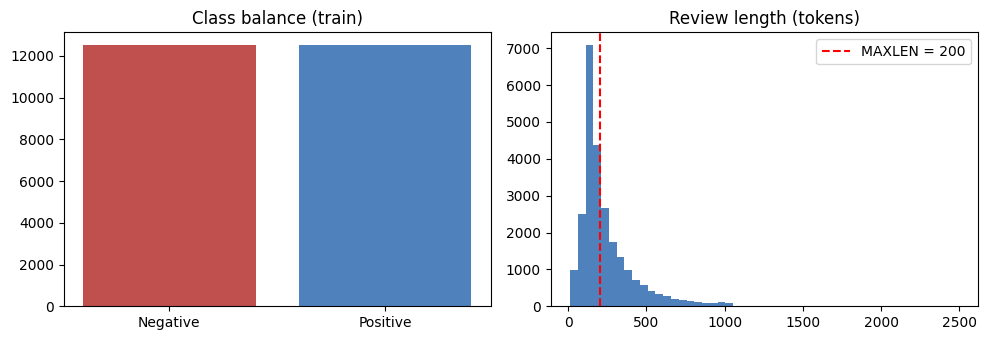

In [3]:
# Class balance and review length distribution
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].bar(["Negative", "Positive"], [int((y_train == 0).sum()), int((y_train == 1).sum())], color=["#c0504d", "#4f81bd"])
ax[0].set_title("Class balance (train)")
ax[1].hist(lengths, bins=50, color="#4f81bd")
ax[1].axvline(MAXLEN, color="red", linestyle="--", label=f"MAXLEN = {MAXLEN}")
ax[1].set_title("Review length (tokens)")
ax[1].legend()
plt.tight_layout()
plt.savefig("screenshots/01_data_overview.png", dpi=150)
plt.show()

## Step 3: Preprocess
Padding makes every review the same length so they can be processed in batches.

In [4]:
x_train = keras.utils.pad_sequences(x_train, maxlen=MAXLEN)
x_test = keras.utils.pad_sequences(x_test, maxlen=MAXLEN)
print("Train shape:", x_train.shape, "| Test shape:", x_test.shape)

Train shape: (25000, 200) | Test shape: (25000, 200)


## Step 4: Build Model A (Embedding + Bidirectional LSTM)
- **Embedding:** turns each word index into a 32-number vector.
- **Bidirectional LSTM:** reads the review forwards and backwards to capture context.
- **Dropout:** reduces overfitting.
- **Dense (sigmoid):** outputs the probability that the review is positive.

In [5]:
def build_lstm():
    m = keras.Sequential([
        keras.Input(shape=(MAXLEN,)),
        keras.layers.Embedding(VOCAB, 32),
        keras.layers.Bidirectional(keras.layers.LSTM(32)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ], name="embedding_bilstm")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

model_lstm = build_lstm()
model_lstm.summary()

Model: "embedding_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,705 (1.28 MB)

 Trainable params: 336,705 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train Model A
Early stopping halts training when validation accuracy stops improving and keeps the best weights.

In [6]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)

t0 = time.time()
hist_lstm = model_lstm.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                           validation_split=0.2, callbacks=[early_stop], verbose=2)
time_lstm = time.time() - t0
print(f"Training time: {time_lstm:.1f} s")

Epoch 1/8
157/157 - 38s - 245ms/step - accuracy: 0.7290 - loss: 0.5238 - val_accuracy: 0.8414 - val_loss: 0.3692
Epoch 2/8
157/157 - 36s - 228ms/step - accuracy: 0.8834 - loss: 0.2936 - val_accuracy: 0.8648 - val_loss: 0.3273
Epoch 3/8
157/157 - 41s - 262ms/step - accuracy: 0.9237 - loss: 0.2088 - val_accuracy: 0.8600 - val_loss: 0.3574
Epoch 4/8
157/157 - 34s - 216ms/step - accuracy: 0.9314 - loss: 0.1872 - val_accuracy: 0.8664 - val_loss: 0.3914
Epoch 5/8
157/157 - 35s - 224ms/step - accuracy: 0.9324 - loss: 0.1777 - val_accuracy: 0.8690 - val_loss: 0.3394
Epoch 6/8
157/157 - 40s - 256ms/step - accuracy: 0.9477 - loss: 0.1482 - val_accuracy: 0.8762 - val_loss: 0.3767
Epoch 7/8
157/157 - 38s - 239ms/step - accuracy: 0.9483 - loss: 0.1436 - val_accuracy: 0.8576 - val_loss: 0.4293
Epoch 8/8
157/157 - 34s - 214ms/step - accuracy: 0.9464 - loss: 0.1429 - val_accuracy: 0.8414 - val_loss: 0.4772
Training time: 303.4 s


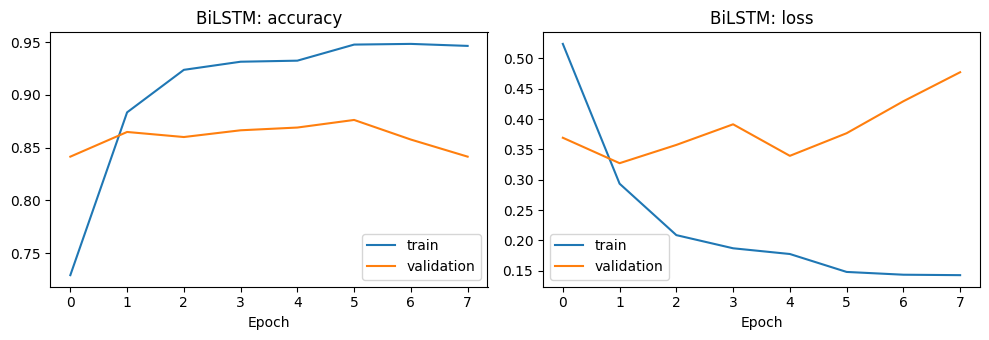

In [7]:
def plot_history(h, title, path):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(h.history["accuracy"], label="train")
    ax[0].plot(h.history["val_accuracy"], label="validation")
    ax[0].set_title(f"{title}: accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()
    ax[1].plot(h.history["loss"], label="train")
    ax[1].plot(h.history["val_loss"], label="validation")
    ax[1].set_title(f"{title}: loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.show()

plot_history(hist_lstm, "BiLSTM", "screenshots/02_training_curves_bilstm.png")

## Step 6: Evaluate Model A on the test set

Test accuracy: 0.8609
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86     12500
    Positive       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



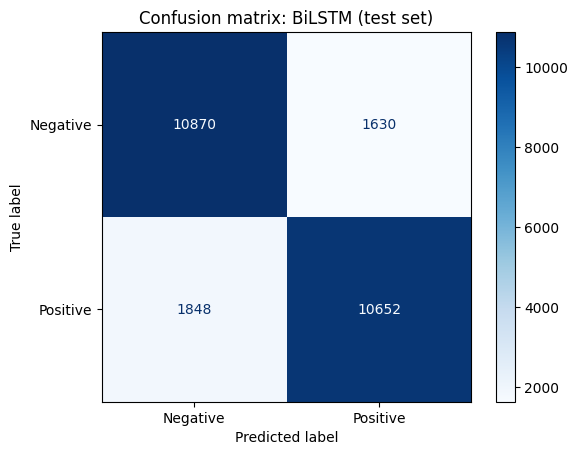

In [8]:
loss_lstm, acc_lstm = model_lstm.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", round(acc_lstm, 4))

probs_lstm = model_lstm.predict(x_test, batch_size=256, verbose=0).ravel()
preds_lstm = (probs_lstm > 0.5).astype(int)

report_lstm = classification_report(y_test, preds_lstm, target_names=["Negative", "Positive"], output_dict=True)
print(classification_report(y_test, preds_lstm, target_names=["Negative", "Positive"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, preds_lstm), display_labels=["Negative", "Positive"]).plot(cmap="Blues")
plt.title("Confusion matrix: BiLSTM (test set)")
plt.savefig("screenshots/03_confusion_matrix_bilstm.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7: Try the model on your own sentences
Keras shifts word indices by 3 (0 = padding, 1 = start, 2 = unknown), so the encoder adds 3 to every index.

In [9]:
word_index = keras.datasets.imdb.get_word_index()

def encode(text):
    ids = [1]  # start token
    cleaned = "".join(ch if ch.isalpha() or ch == "'" else " " for ch in text.lower())
    for w in cleaned.split():
        i = word_index.get(w)
        ids.append(i + 3 if (i is not None and i + 3 < VOCAB) else 2)
    return keras.utils.pad_sequences([ids], maxlen=MAXLEN)

def predict(model, text):
    return float(model.predict(encode(text), verbose=0)[0][0])

my_reviews = [
    "This movie was fantastic, I loved every minute of it",
    "Terrible plot and awful acting, a complete waste of time",
    "A beautiful story with brilliant performances and a moving ending",
    "Boring, predictable and far too long. I almost fell asleep",
    "Not bad, but not great either. It had some good moments",
]
demo_rows = []
for r in my_reviews:
    p = predict(model_lstm, r)
    label = "Positive" if p > 0.5 else "Negative"
    demo_rows.append((r, round(p, 3), label))
    print(f"{p:.2f} -> {label:8s} | {r}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
0.91 -> Positive | This movie was fantastic, I loved every minute of it
0.00 -> Negative | Terrible plot and awful acting, a complete waste of time
0.99 -> Positive | A beautiful story with brilliant performances and a moving ending
0.02 -> Negative | Boring, predictable and far too long. I almost fell asleep
0.56 -> Positive | Not bad, but not great either. It had some good moments


## Step 8: Comparison model B (Embedding + GlobalAveragePooling)
A much simpler model with no recurrence. It trains faster, so the table below shows the accuracy vs. speed trade-off.

Epoch 1/8
157/157 - 3s - 22ms/step - accuracy: 0.6671 - loss: 0.6489 - val_accuracy: 0.7872 - val_loss: 0.5333
Epoch 2/8
157/157 - 2s - 15ms/step - accuracy: 0.8307 - loss: 0.4235 - val_accuracy: 0.8590 - val_loss: 0.3514
Epoch 3/8
157/157 - 2s - 14ms/step - accuracy: 0.8755 - loss: 0.3097 - val_accuracy: 0.8714 - val_loss: 0.3125
Epoch 4/8
157/157 - 3s - 17ms/step - accuracy: 0.9000 - loss: 0.2586 - val_accuracy: 0.8770 - val_loss: 0.2990
Epoch 5/8
157/157 - 5s - 29ms/step - accuracy: 0.9141 - loss: 0.2254 - val_accuracy: 0.8768 - val_loss: 0.2955
Epoch 6/8
157/157 - 2s - 16ms/step - accuracy: 0.9248 - loss: 0.2004 - val_accuracy: 0.8772 - val_loss: 0.2957
Epoch 7/8
157/157 - 2s - 14ms/step - accuracy: 0.9348 - loss: 0.1781 - val_accuracy: 0.8738 - val_loss: 0.3041
Epoch 8/8
157/157 - 2s - 15ms/step - accuracy: 0.9421 - loss: 0.1617 - val_accuracy: 0.8746 - val_loss: 0.3116
Test accuracy: 0.8738 | Training time: 22.6 s


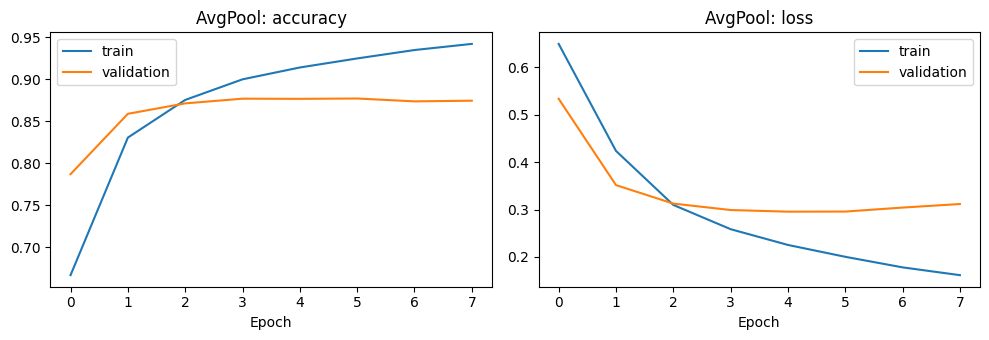

In [10]:
def build_pool():
    m = keras.Sequential([
        keras.Input(shape=(MAXLEN,)),
        keras.layers.Embedding(VOCAB, 32),
        keras.layers.GlobalAveragePooling1D(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ], name="embedding_avgpool")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

model_pool = build_pool()
early_stop2 = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)

t0 = time.time()
hist_pool = model_pool.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                           validation_split=0.2, callbacks=[early_stop2], verbose=2)
time_pool = time.time() - t0

loss_pool, acc_pool = model_pool.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc_pool:.4f} | Training time: {time_pool:.1f} s")
plot_history(hist_pool, "AvgPool", "screenshots/04_training_curves_avgpool.png")

## Step 9: Comparison table and results files

| Model | Test accuracy | Training time (s) | Parameters | Epochs run |
|---|---|---|---|---|
| Embedding + BiLSTM | 0.8609 | 303.4 | 336,705 | 8 |
| Embedding + GlobalAvgPool | 0.8738 | 22.6 | 321,089 | 8 |


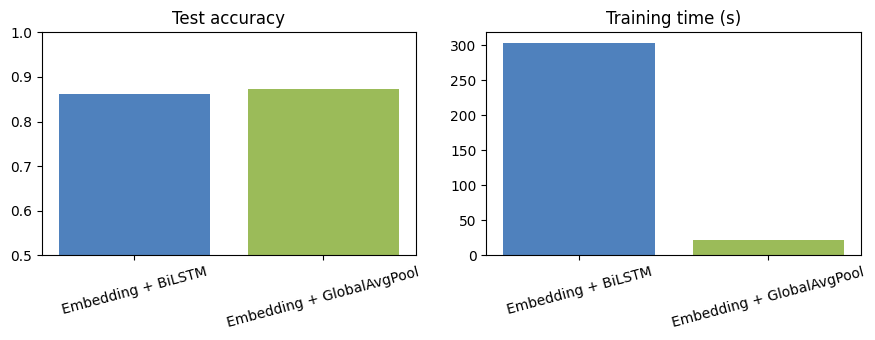


Saved: results.json, results_summary.md and 5 images in screenshots/


In [11]:
results = {
    "Embedding + BiLSTM": {"test_accuracy": round(float(acc_lstm), 4),
                           "train_seconds": round(time_lstm, 1),
                           "parameters": int(model_lstm.count_params()),
                           "epochs_run": len(hist_lstm.history["loss"])},
    "Embedding + GlobalAvgPool": {"test_accuracy": round(float(acc_pool), 4),
                                  "train_seconds": round(time_pool, 1),
                                  "parameters": int(model_pool.count_params()),
                                  "epochs_run": len(hist_pool.history["loss"])},
}

lines = ["| Model | Test accuracy | Training time (s) | Parameters | Epochs run |",
         "|---|---|---|---|---|"]
for name, r in results.items():
    lines.append(f"| {name} | {r['test_accuracy']:.4f} | {r['train_seconds']} | {r['parameters']:,} | {r['epochs_run']} |")
table_md = "\n".join(lines)
print(table_md)

# Bar chart for the comparison
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
names = list(results.keys())
ax[0].bar(names, [results[n]["test_accuracy"] for n in names], color=["#4f81bd", "#9bbb59"])
ax[0].set_ylim(0.5, 1.0); ax[0].set_title("Test accuracy")
ax[1].bar(names, [results[n]["train_seconds"] for n in names], color=["#4f81bd", "#9bbb59"])
ax[1].set_title("Training time (s)")
for a in ax: a.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); plt.savefig("screenshots/05_model_comparison.png", dpi=150); plt.show()

with open("results.json", "w") as f:
    json.dump({"results": results,
               "bilstm_report": report_lstm,
               "demo_predictions": [{"review": r, "prob_positive": p, "label": l} for r, p, l in demo_rows]}, f, indent=2)

summary = "## Results\n\n" + table_md + "\n\n**BiLSTM per-class metrics (test set)**\n\n| Class | Precision | Recall | F1 |\n|---|---|---|---|\n"
for cls in ["Negative", "Positive"]:
    m = report_lstm[cls]
    summary += f"| {cls} | {m['precision']:.3f} | {m['recall']:.3f} | {m['f1-score']:.3f} |\n"
with open("results_summary.md", "w") as f:
    f.write(summary)
print("\nSaved: results.json, results_summary.md and 5 images in screenshots/")

## Step 10: Save the trained model

In [12]:
model_lstm.save("sentiment_model.keras")
print("Saved sentiment_model.keras")

Saved sentiment_model.keras
